In [1]:
import os
import numpy as np
import pandas as pd
import bioframe as bf
import bbi
import matplotlib.pyplot as plt
from coolpuppy import coolpup
import matplotlib as _mpl, matplotlib.cm as _cm
if not hasattr(_cm, "register_cmap"):
    _cm.register_cmap = lambda name=None, cmap=None, **k: _mpl.colormaps.register(cmap, name=name, force=True)
from coolpuppy import plotpup
from scipy.stats import mannwhitneyu
import seaborn as sns

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
NPROC = 8
resolution = 10_000
samples = ['WTnoUV', 'WT3h', 'XPCnoUV']

In [3]:
view_df = prepare_view_df()

In [4]:
clr_ = CLR_CONNS(resolution=resolution)
view_df = prepare_view_df(arm=True)
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution // 1000, label='arm') for k in samples}

In [5]:
STD_CHROMS = [f'chr{c}' for c in list(range(1, 23)) + ['X']]
IDR_MIN_SCORE = 540

def read_peaks(path):
    # narrowPeak cols: chrom start end name SCORE strand signalValue pValue qValue peak
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0, 1, 2, 4, 5, 9],
                     names=['chrom', 'start', 'end', 'score', 'strand', 'summitStart'])
    df = df[(df['chrom'].isin(STD_CHROMS)) & (df['score'] >= IDR_MIN_SCORE)].copy()
    df['start'] = df['start'] + df['summitStart']
    df['end'] = df['start'] + 1
    return df.sort_values(['chrom', 'start'])[['chrom', 'start', 'end', 'score', 'strand']]

idr_peaks = {
    'WTnoUV': read_peaks('/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak'),
    'XPCnoUV': read_peaks('/home/carlos/oldies/ner_collab/ctcf/idr/XPCKO_NoUV_idr_conservative_merged.narrowPeak'),
    'WT3h': read_peaks('/home/carlos/oldies/ner_collab/ctcf/idr/WT_3h_idr_conservative_merged.narrowPeak')
}

In [6]:
MOTIF    = '/home/carlos/Clone/ggner-3d/data/CTCF_hg38.bed'
motif = pd.read_csv(MOTIF, sep='\t', header=None,
                    names=['chrom', 'start', 'end', 'x3', 'strand', 'name', 'mscore', 'pval', 'qval', 'seq'])
motif = motif[motif['chrom'].isin(STD_CHROMS)][['chrom', 'start', 'end', 'strand', 'mscore']]

In [7]:
motif['m_id'] = motif['chrom'] + ':' + motif['start'].astype(str) + '-' + motif['end'].astype(str) + ':' + motif['strand']

<Axes: xlabel='mscore', ylabel='Count'>

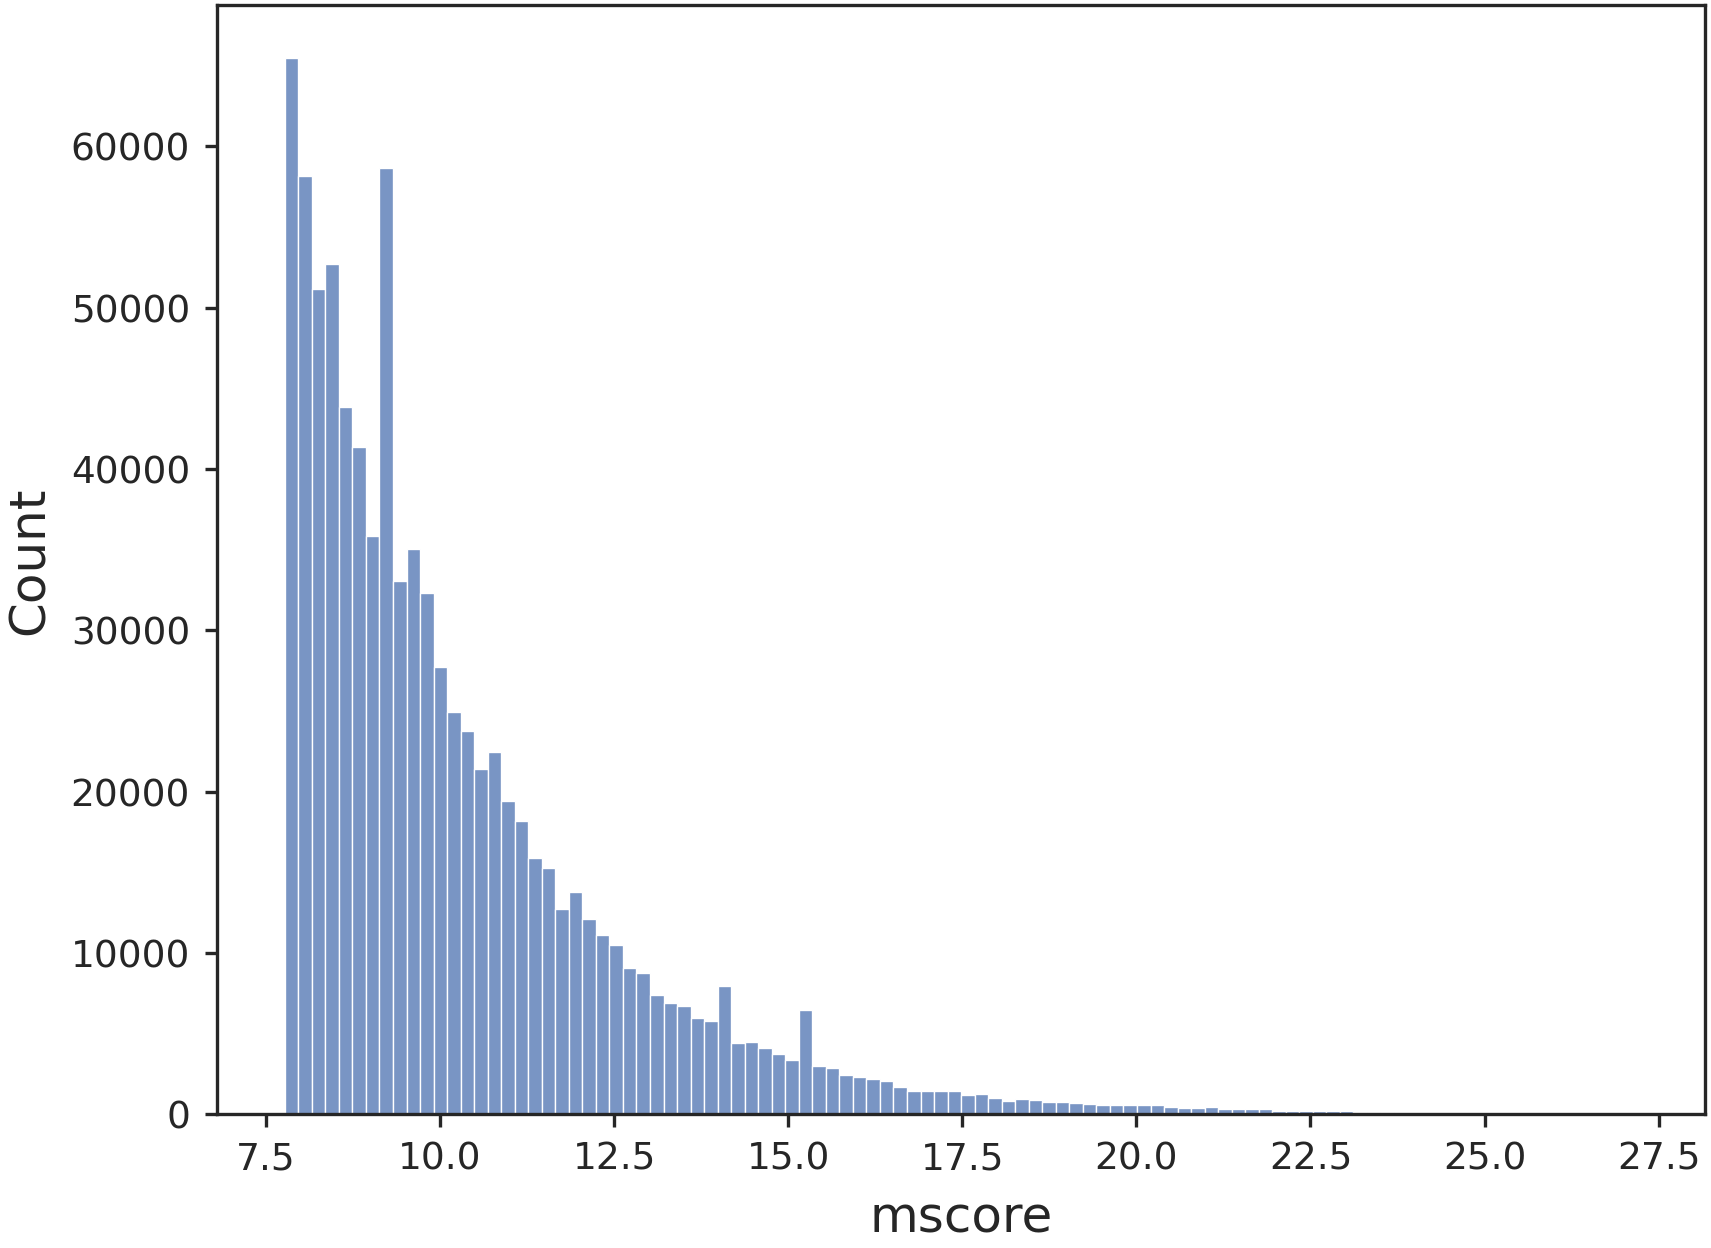

In [8]:
sns.histplot(motif['mscore'], bins=100)

In [9]:
matched_motifs = {}
all_motifs = {}

for sample in samples:
    peaks = idr_peaks[sample]

    clo_ = bf.closest(motif, peaks)
    clo_ = clo_[clo_['distance'] <= 19]  # length of JASPAR motif is 19 bp, MA0139.1

    clo_ = clo_[['chrom', 'start_', 'end_', 'score_', 'strand', 'mscore', 'm_id']].copy()

    print(f'{sample}: {len(clo_)} matched motifs')

    matched_motifs[sample] = clo_
    all_motifs[sample] = clo_['m_id'].unique()

# motif IDs present in every sample
common = set.intersection(*(set(v) for v in all_motifs.values()))

print(f'{len(common)} common motif IDs')

# one-row-per-common-motif dataframe
# use any sample here, because all common m_id values are present in every sample
common_motifs_df = (
    matched_motifs[samples[0]]
    .loc[lambda df: df['m_id'].isin(common)]
    .drop_duplicates('m_id')
    .copy()
)

print(common_motifs_df.shape)

WTnoUV: 33291 matched motifs
WT3h: 15706 matched motifs
XPCnoUV: 23972 matched motifs
14030 common motif IDs
(14030, 7)


In [10]:
common_motifs_df = common_motifs_df.sort_values(['chrom', 'start_']).reset_index(drop=True)

In [11]:
common_motifs_df.rename(columns={'start_': 'start', 'end_': 'end', 'score_': 'score'}, inplace=True)

In [12]:
pups = {}
for sample in samples:
    pup = coolpup.pileup(clr_[sample], common_motifs_df, features_format='bed', view_df=view_df,
                            expected_df=expected_[sample],
                            by_strand=True, mindist=100_000, maxdist=1_000_000,
                            flank=300_000, nproc=NPROC,
                            store_stripes=True)
    pups[sample] = pup

INFO:coolpuppy:('chr5_p', 'chr5_p'): 634
INFO:coolpuppy:('chr6_p', 'chr6_p'): 3186
INFO:coolpuppy:('chr3_p', 'chr3_p'): 2252
INFO:coolpuppy:('chr1_p', 'chr1_p'): 7649
INFO:coolpuppy:('chr4_p', 'chr4_p'): 830
INFO:coolpuppy:('chr8_p', 'chr8_p'): 1220
INFO:coolpuppy:('chr7_p', 'chr7_p'): 2441
INFO:coolpuppy:('chr2_p', 'chr2_p'): 3299
INFO:coolpuppy:('chr3_q', 'chr3_q'): 2327
INFO:coolpuppy:('chr1_q', 'chr1_q'): 5904
INFO:coolpuppy:('chr5_q', 'chr5_q'): 2839
INFO:coolpuppy:('chr6_q', 'chr6_q'): 741
INFO:coolpuppy:('chr2_q', 'chr2_q'): 4142
INFO:coolpuppy:('chr4_q', 'chr4_q'): 616
INFO:coolpuppy:('chr8_q', 'chr8_q'): 1873
INFO:coolpuppy:('chr7_q', 'chr7_q'): 2023
INFO:coolpuppy:('chr9_p', 'chr9_p'): 840
INFO:coolpuppy:('chr11_p', 'chr11_p'): 2406
INFO:coolpuppy:('chr12_p', 'chr12_p'): 1841
INFO:coolpuppy:('chr10_p', 'chr10_p'): 1073
INFO:coolpuppy:('chr16_p', 'chr16_p'): 1815
INFO:coolpuppy:('chr9_q', 'chr9_q'): 2666
INFO:coolpuppy:('chr11_q', 'chr11_q'): 5709
INFO:coolpuppy:('chr12_q', 'c

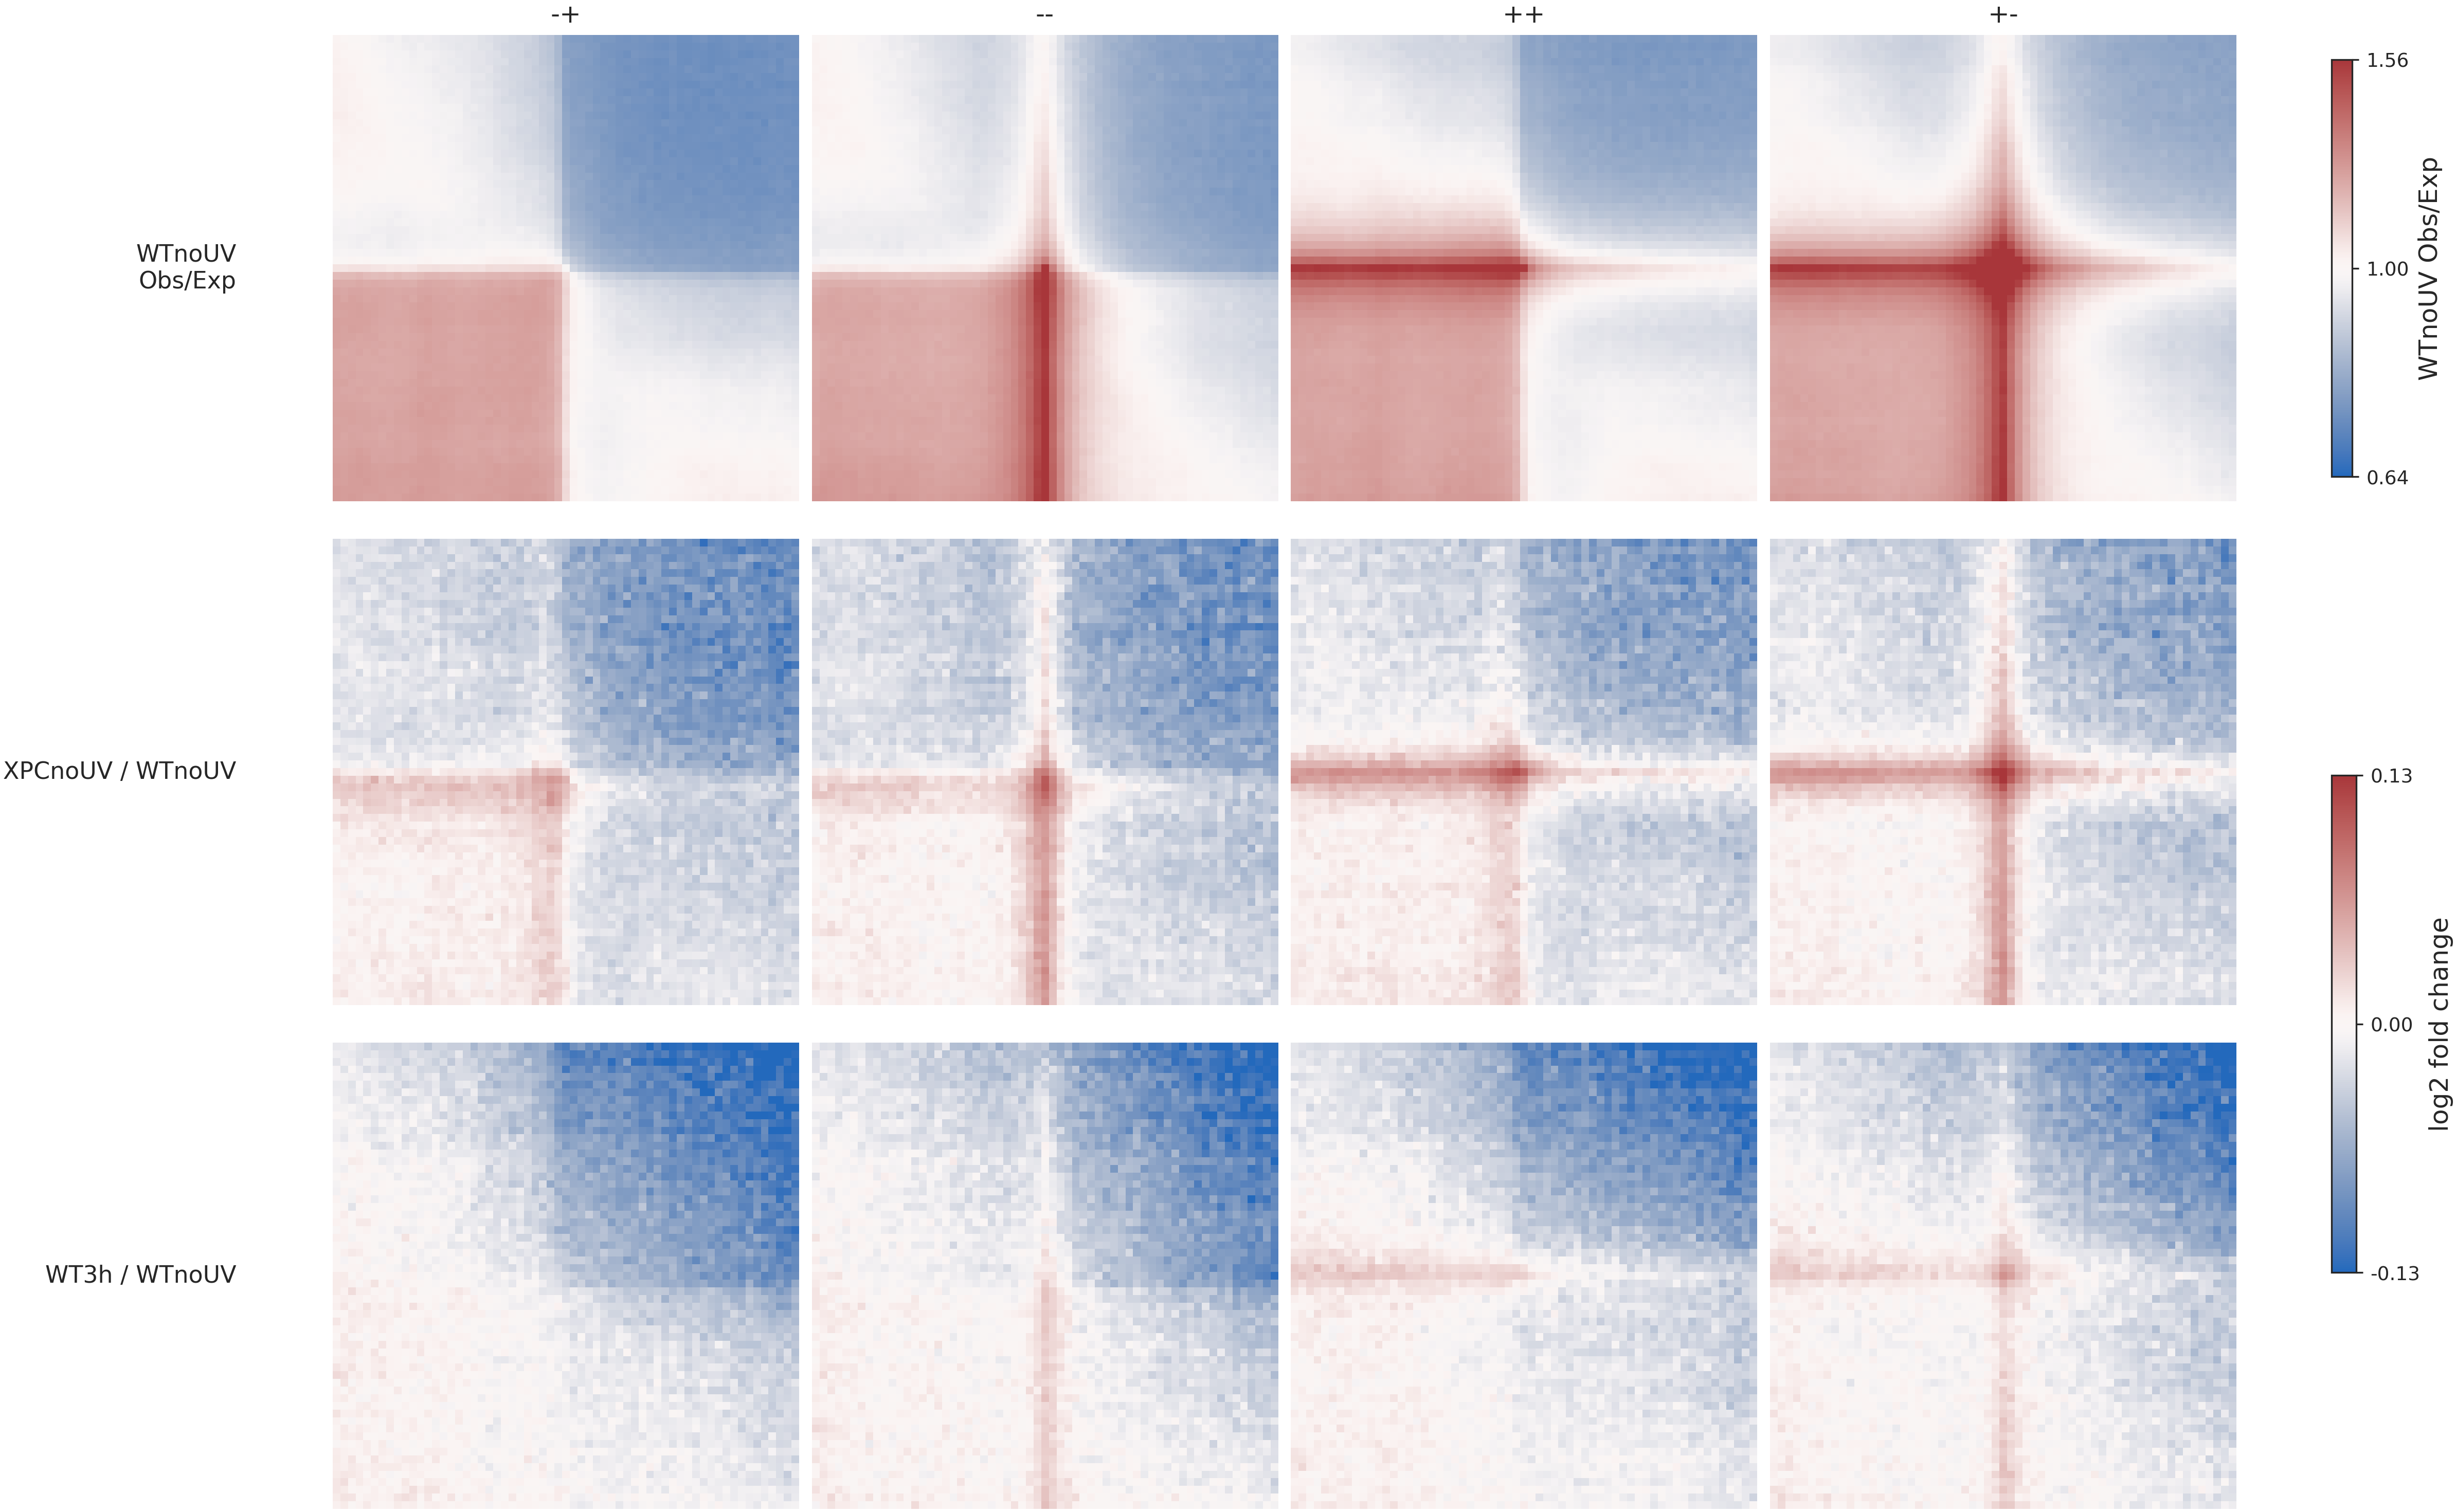

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize, LogNorm
from matplotlib.ticker import FuncFormatter

orientations = ['-+', '--', '++', '+-']
comps = [('WTnoUV', 'XPCnoUV'), ('WTnoUV', 'WT3h')]
BASE = 'WTnoUV'

cmap = mpl.colormaps['vlag'].copy()
cmap.set_bad((0.98, 0.98, 0.98))

def get_orient(sample, orientation):
    return pups[sample].loc[pups[sample]["orientation"] == orientation].data.values[0]

oe, fc = {}, {}
for cc, orientation in enumerate(orientations):
    oe[cc] = get_orient(BASE, orientation)
    for k, (c1, c2) in enumerate(comps):
        fc[(k, cc)] = (np.log2(get_orient(c2, orientation) + 1e-6)
                       - np.log2(get_orient(c1, orientation) + 1e-6))

oe_vals = np.concatenate([np.ravel(v[np.isfinite(v) & (v > 0)]) for v in oe.values()])
VOE = np.nanpercentile(oe_vals, 99.5)
norm_oe = LogNorm(1 / VOE, VOE)
VMAX = np.nanpercentile(np.concatenate([np.ravel(np.abs(m)) for m in fc.values()]), 99.5)
norm_fc = Normalize(-VMAX, VMAX)

fig, ax = plt.subplots(3, len(orientations), figsize=(16, 10), constrained_layout=True)

for cc, orientation in enumerate(orientations):
    a = ax[0, cc]
    mm = oe[cc].copy(); mm[~(mm > 0)] = np.nan
    a.imshow(mm, cmap=cmap, norm=norm_oe, interpolation='none', rasterized=True)
    a.set_xticks([]); a.set_yticks([])
    for sp in a.spines.values(): sp.set_visible(False)
    a.set_title(orientation, fontsize=12)
    if cc == 0:
        a.set_ylabel(f'{BASE}\nObs/Exp', fontsize=11, rotation=0, ha='right', va='center', labelpad=45)

for k, (c1, c2) in enumerate(comps):
    for cc, orientation in enumerate(orientations):
        a = ax[k + 1, cc]
        a.imshow(fc[(k, cc)], cmap=cmap, norm=norm_fc, interpolation='none', rasterized=True)
        a.set_xticks([]); a.set_yticks([])
        for sp in a.spines.values(): sp.set_visible(False)
        if cc == 0:
            a.set_ylabel(f'{c2} / {c1}', fontsize=11, rotation=0, ha='right', va='center', labelpad=45)

cb_oe = fig.colorbar(mpl.cm.ScalarMappable(norm=norm_oe, cmap=cmap),
                     ax=ax[0, :].tolist(), shrink=0.85, label=f'{BASE} Obs/Exp')
cb_oe.minorticks_off()
cb_oe.set_ticks([1 / VOE, 1, VOE])
cb_oe.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

cb_fc = fig.colorbar(mpl.cm.ScalarMappable(norm=norm_fc, cmap=cmap),
                     ax=ax[1:, :].ravel().tolist(), shrink=0.5,
                     label='log2 fold change', ticks=[-VMAX, 0, VMAX])
cb_fc.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# save: heatmaps rasterized (via rasterized=True), text/labels/spines stay vector
fig.savefig('/home/carlos/Clone/ggner-3d/figs/stripes/ctcf_stripes_orientation_grid.svg',
            dpi=300, bbox_inches='tight')
plt.show()
